In [38]:
# Номера рядов: 17, 284, 593
# Импорты

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# Загрузим все ряды

df = pd.read_excel(
    "M3C.xls",        # путь к файлу
    sheet_name="M3Year",
    usecols='G:Z'  # столбцы 1-20 (в pandas нумерация с 0)
)

print(df)

          1        2        3        4        5        6        7        8   \
0     940.66  1084.86  1244.98  1445.02  1683.17  2038.15  2342.52  2602.45   
1    1991.05  2306.40  2604.00  2992.30  3722.08  5226.62  5989.46  5614.62   
2    1461.57  1692.50  2193.82  2459.68  3246.80  4748.86  5559.46  5292.42   
3     744.54  1105.16  1417.40  1838.04  2337.62  3094.88  4280.04  5070.20   
4    4977.18  5248.00  5370.00  6184.89  7137.19  6743.00  7298.00  5260.29   
..       ...      ...      ...      ...      ...      ...      ...      ...   
640  5980.00  4970.00  5020.00  3820.00  4510.00  5460.00  5650.00  4320.00   
641  4950.00  6610.00  6860.00  6460.00  5390.00  6850.00  5220.00  7420.00   
642  5700.00  4420.00  5900.00  6810.00  4960.00  5420.00  5320.00  5100.00   
643  6480.00  5470.00  2790.00  7570.00  7140.00  6810.00  7150.00  6880.00   
644  6030.00  5070.00  5970.00  7870.00  5490.00  7600.00  5620.00  5040.00   

          9        10       11       12       13   

<Axes: >

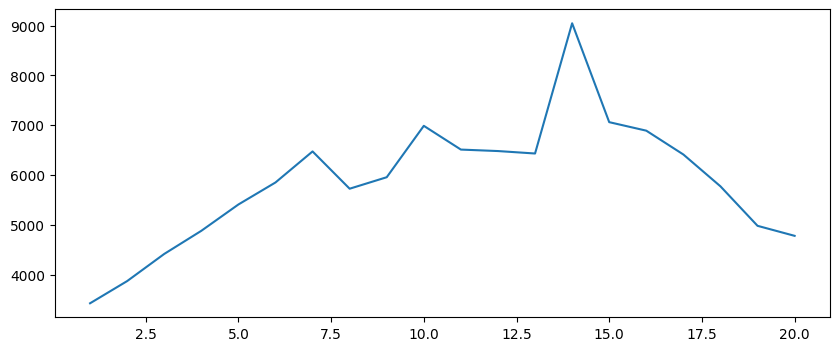

In [52]:
# Первый ряд

test_size = 4
series = df.iloc[17]
train = series[:-test_size]
test = series[-test_size:]
series.plot(figsize=(10,4))

# Сезонности нет

In [23]:
# Подберем d с помощью ADF

from statsmodels.tsa.stattools import adfuller

result = adfuller(series)

print("ADF statistic:", result[0])
print("p-value:", result[1])

# Значения пороговые


ADF statistic: -2.8476244014467627
p-value: 0.05178637422170261


In [26]:
# Получили пороговые значения у предыдущего теста, посмотрим kpss

from statsmodels.tsa.stattools import kpss

stat, p, _, _ = kpss(series)

print("kpss statistic:", stat)
print("p-value:", p)

kpss statistic: 0.351180796509397
p-value: 0.09819793253905301


ADF ~ 0.05, KPSS > 0.05 => ряд стационарен, d = 0

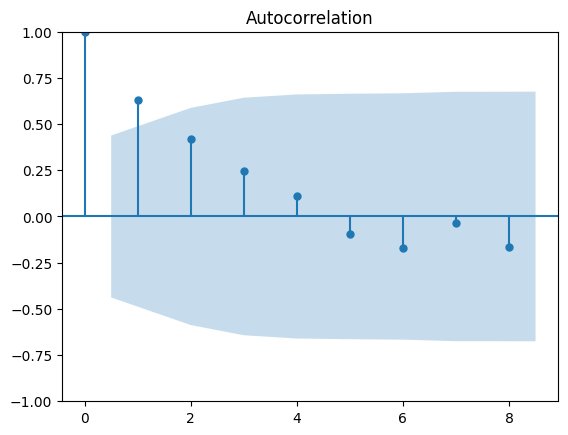

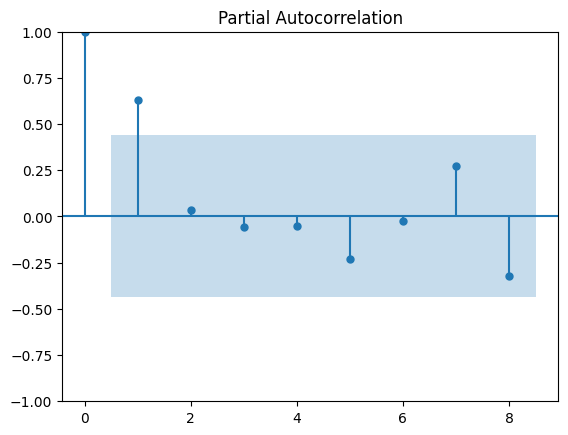

In [27]:
# Подбираем p/q с помощью PACF/ACF

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt


plot_acf(series, lags=8)
plt.show()

plot_pacf(series, lags=8)
plt.show()

Трудно сказать, каков оптимальный q, но p должен быть = 1

In [53]:
# Подберем перебором небольших значений и выберем по лучшему AIC

import itertools

from statsmodels.tsa.arima.model import ARIMA


p = q = range(0, 2)
d = [0]


best_aic = np.inf
best_params = None

for params in itertools.product(p, d, q):

        try:
            model = ARIMA(
                train,
                order=params
            )

            result = model.fit()
            if result.aic < best_aic:
                best_aic = result.aic
                best_params = params

        except:
            continue

print("Best model:", best_params)
print("Best AIC:", best_aic)

Best model: (1, 0, 0)
Best AIC: 270.87053659534564


Перебор подтвердил наши предположения, поэтому будем использовать именно эту модель

In [54]:
# Прогноз на test и метрики

from sklearn.metrics import mean_absolute_error, mean_squared_error

model = ARIMA(train,order=(1,0,0))

fitted_model = model.fit()

test_forecast = fitted_model.forecast(steps=test_size)

mae = mean_absolute_error(test, test_forecast)
rmse = np.sqrt(mean_squared_error(test, test_forecast))
smape = 100/len(test) * np.sum(2 * np.abs(test_forecast - test) / (np.abs(test) + np.abs(test_forecast)))

print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"sMAPE = {smape:.2f}%")

MAE  = 860.757
RMSE = 980.310
sMAPE = 7.13%


In [55]:
# Предсказание на модели, обученной на всех данных

model = ARIMA(series,order=(1,0,0))

final_fit = model.fit()

forecast_steps = 4
future_forecast = final_fit.forecast(steps=forecast_steps)

print("\n=== Прогноз на 4 года ===")
print(future_forecast)


=== Прогноз на 4 года ===
20    4930.289270
21    5044.226643
22    5132.006675
23    5199.634477
Name: predicted_mean, dtype: float64


<Axes: >

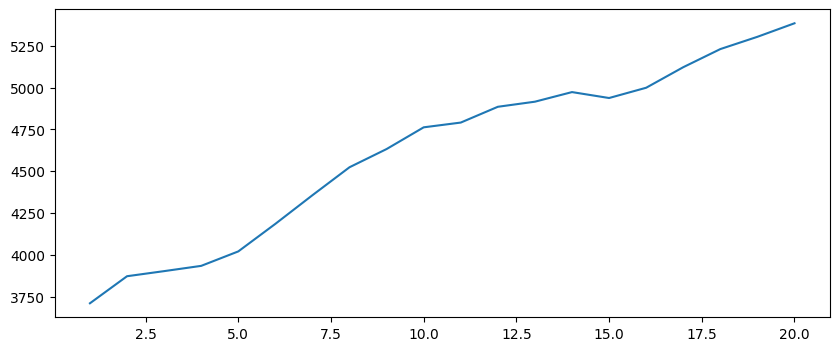

In [57]:
# Второй ряд

test_size = 4
series = df.iloc[284]
train = series[:-test_size]
test = series[-test_size:]
series.plot(figsize=(10,4))

# Сезонности нет

In [60]:
# Подберем d с помощью ADF

from statsmodels.tsa.stattools import adfuller

result = adfuller(series)

print("ADF statistic:", result[0])
print("p-value:", result[1])

# Вывод: ряд нестационарен, нужно дифференциировать

ADF statistic: -1.3345071976870102
p-value: 0.6132411469607044


In [61]:
# Сделаем ADF для производных

result = adfuller(series.diff().dropna())

print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -2.991091779507172
p-value: 0.035734732306886015


Получили p < 0.5 => d = 1

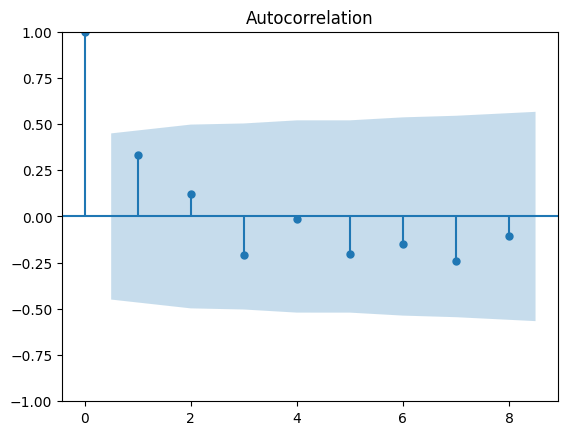

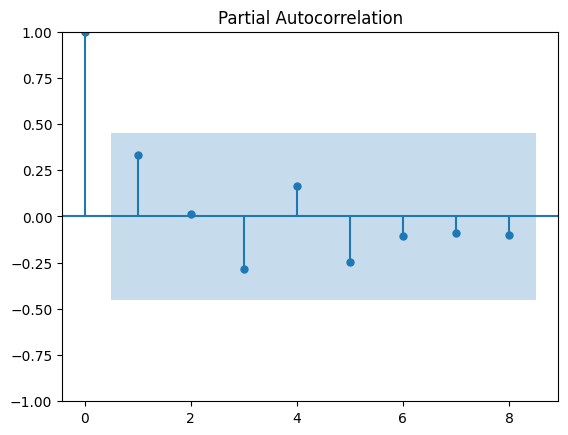

In [62]:
# Подбираем p/q с помощью PACF/ACF

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt


plot_acf(series.diff().dropna(), lags=8)
plt.show()

plot_pacf(series.diff().dropna(), lags=8)
plt.show()

Ничего не понятно

In [63]:
# Подберем перебором небольших значений и выберем по лучшему AIC

import itertools

from statsmodels.tsa.arima.model import ARIMA


p = q = range(0, 2)
d = [1]


best_aic = np.inf
best_params = None

for params in itertools.product(p, d, q):

        try:
            model = ARIMA(
                train,
                order=params
            )

            result = model.fit()
            if result.aic < best_aic:
                best_aic = result.aic
                best_params = params

        except:
            continue

print("Best model:", best_params)

Best model: (1, 1, 0)


In [64]:
# Прогноз на test и метрики

from sklearn.metrics import mean_absolute_error, mean_squared_error

model = ARIMA(train,order=(1,1,0))

fitted_model = model.fit()

test_forecast = fitted_model.forecast(steps=test_size)

mae = mean_absolute_error(test, test_forecast)
rmse = np.sqrt(mean_squared_error(test, test_forecast))
smape = 100/len(test) * np.sum(2 * np.abs(test_forecast - test) / (np.abs(test) + np.abs(test_forecast)))

print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"sMAPE = {smape:.2f}%")

MAE  = 160.585
RMSE = 171.761
sMAPE = 1.47%


In [65]:
# Предсказание на модели, обученной на всех данных

model = ARIMA(series,order=(1,1,0))

final_fit = model.fit()

forecast_steps = 4
future_forecast = final_fit.forecast(steps=forecast_steps)

print("\n=== Прогноз на 4 года ===")
print(future_forecast)


=== Прогноз на 4 года ===
20    5453.264580
21    5509.122898
22    5555.509149
23    5594.029540
Name: predicted_mean, dtype: float64


<Axes: >

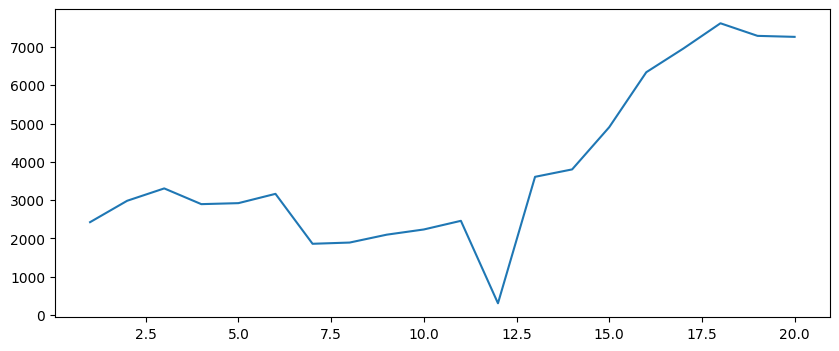

In [66]:
# Третий ряд

test_size = 4
series = df.iloc[593]
train = series[:-test_size]
test = series[-test_size:]
series.plot(figsize=(10,4))

# Сезонности нет

In [67]:
# Подберем d с помощью ADF

from statsmodels.tsa.stattools import adfuller

result = adfuller(series)

print("ADF statistic:", result[0])
print("p-value:", result[1])

# Вывод: ряд стационарен, d = 0

ADF statistic: -1.778832930685753
p-value: 0.39102003119576845


In [74]:
# Получили пороговые значения у предыдущего теста, посмотрим kpss

from statsmodels.tsa.stattools import kpss

stat, p, _, _ = kpss(series)

print("kpss statistic:", stat)
print("p-value:", p)

kpss statistic: 0.5044975267907007
p-value: 0.04065371018227462


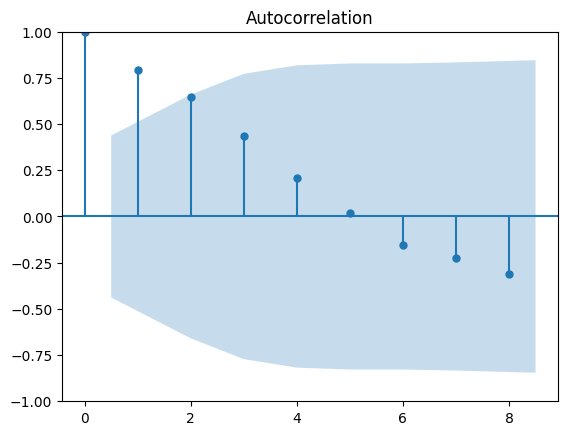

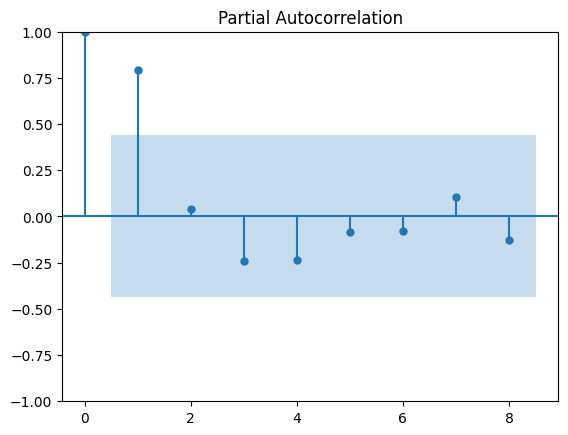

In [69]:
# Подбираем p/q с помощью PACF/ACF

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt


plot_acf(series, lags=8)
plt.show()

plot_pacf(series, lags=8)
plt.show()

In [73]:
# Подберем перебором небольших значений и выберем по лучшему AIC

import itertools

from statsmodels.tsa.arima.model import ARIMA


p = q = range(0, 2)
d = range(0, 2)


best_aic = np.inf
best_params = None

for params in itertools.product(p, d, q):

        try:
            model = ARIMA(
                train,
                order=params
            )

            result = model.fit()
            if result.aic < best_aic:
                best_aic = result.aic
                best_params = params

        except:
            continue

print("Best model:", best_params)

Best model: (0, 1, 0)


In [75]:
# Прогноз на test и метрики

from sklearn.metrics import mean_absolute_error, mean_squared_error

model = ARIMA(train,order=(0,1,0))

fitted_model = model.fit()

test_forecast = fitted_model.forecast(steps=test_size)

mae = mean_absolute_error(test, test_forecast)
rmse = np.sqrt(mean_squared_error(test, test_forecast))
smape = 100/len(test) * np.sum(2 * np.abs(test_forecast - test) / (np.abs(test) + np.abs(test_forecast)))

print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"sMAPE = {smape:.2f}%")

MAE  = 943.000
RMSE = 971.504
sMAPE = 10.39%


In [76]:
# Предсказание на модели, обученной на всех данных

model = ARIMA(series,order=(1,1,0))

final_fit = model.fit()

forecast_steps = 4
future_forecast = final_fit.forecast(steps=forecast_steps)

print("\n=== Прогноз на 4 года ===")
print(future_forecast)


=== Прогноз на 4 года ===
20    7268.852464
21    7268.281638
22    7268.366218
23    7268.353686
Name: predicted_mean, dtype: float64
